In [31]:
from pathlib import Path
import numpy as np
from tqdm import tqdm
import json
import pickle
import warnings
from scipy import constants as cs
from scipy import signal
from abc import ABC, abstractmethod
import sympy
from dataclasses import dataclass
from typing import Union, Callable
from matplotlib import pyplot as plt
from IPython.display import display

## Defining classes for carrying variables

In [32]:
Scalar = Union[float, int]
Field  = Union[Scalar, Callable[[np.ndarray], np.ndarray]]

@dataclass
class Drone:
    name: str
    N: int
    L_1: float
    L_2: float
    f_rot: float

@dataclass
class Radar:
    λ: float
    f_c: float

@dataclass
class Context:
    R:       Field
    V_rad:   Field
    θ:       Field
    Φ_p:     Field
    A_r:     Field
    snr:     Field
    t_start: float
    t_stop:  float
    dt:      float

    def resolve(self, field, t: np.ndarray) -> np.ndarray:
        return field(t) if callable(field) else np.full_like(t, field, dtype=float)

## Defining selected drones and radar

In [33]:
λ = 0.02998
default_radar = Radar(
    λ = λ,
    f_c = cs.c/λ
)


djimavicair2 = Drone(
    name="DJI_Mavic_Air_2",
    N=2,
    L_1=0.005,
    L_2=0.07,
    f_rot=91.66,
)

djimavicmini = Drone(
    name="DJI_Mavic_Mini",
    N=2,
    L_1=0.005,
    L_2=0.035,
    f_rot=160,
)

djimatrice300rtk = Drone(
    name="DJI_Matrice_300_RTK",
    N=2,
    L_1=0.05,
    L_2=0.2665,
    f_rot=70,
)

parrotdisco = Drone(
    name="Parrot_Disco",
    N=2,
    L_1=0.01,
    L_2=0.104,
    f_rot=40,
)

djiphantom4 = Drone(
    name="DJI_Phantom_4",
    N=2,
    L_1=0.006,
    L_2=0.05,
    f_rot=116,
)

class_map = ["DJI_Matrice_300_RTK", "DJI_Mavic_Air_2",
             "DJI_Mavic_Mini", "DJI_Phantom_4", "Parrot_Disco"]

drones = [djimatrice300rtk, djimavicair2, djimavicmini, djiphantom4, parrotdisco]

## Implementing noise models

In [34]:
class BaseNoiseModel(ABC):
    def __init__(self):
        self.params_set_flag = False

    @abstractmethod
    def set_parameters(self, params):
        pass

    @abstractmethod
    def apply_noise(self, signal, signal_params):
        pass

class AdditiveWhiteGaussianNoise(BaseNoiseModel):
    def __init__(self, sigma=None):
        super().__init__()
        if sigma is not None:
            self.sigma = sigma
            self.params_set_flag = True

    def set_parameters(self, params):
        if "sigma" in params.keys():
            self.sigma = params["sigma"]
            self.params_set_flag=True
        else:
            raise ValueError("A key with sigma value is not present in params dictionary")

    def apply_noise(self, signal, signal_params=None):
        noise = (np.random.randn(*signal.shape) + 1j * np.random.randn(*signal.shape)) * (self.sigma / np.sqrt(2))
        return signal+noise

## Creation of synthetic data

In [35]:
class SyntheticSignalGenerator:
    def __init__(self, drone: Drone, radar: Radar, noise_model=None):
        self.drone = drone
        self.radar = radar
        self.noise_model = noise_model

        self.base_Psi_f = self._prepare_Psi_functions()

    def _prepare_sympy_Psi_function(self):
        theta, Phi_p, f_rot, t, lamb, A_r, f_c, R, V_rad, L_1, L_2 = sympy.symbols("θ Φ_p f_rot t λ A_r f_c, R, V_rad, L_1, L_2")
        n, N = sympy.symbols("n N", integer=True, positive=True)

        alpha = sympy.sin(sympy.Abs(theta) + Phi_p) + sympy.sin(sympy.Abs(theta) - Phi_p)
        beta  = sympy.sign(theta) * alpha
        Omega_n = 2 * sympy.pi * (f_rot * t + n / N)
        gamma_n = 4 * sympy.pi / lamb * sympy.cos(theta) * sympy.sin(Omega_n)

        first_part = A_r * sympy.exp(sympy.I*(2*sympy.pi*f_c*t - 4*sympy.pi/lamb*(R+V_rad*t)))

        # alpha, beta, Omega_n, gamma_n = sympy.symbols("α β Ω_n γ_n") # Just for verifying the equation

        element_second_part = (alpha + beta * sympy.cos(Omega_n)) * sympy.exp(-sympy.I*(L_1+L_2)/2) * sympy.sinc((L_2-L_1)/2*gamma_n)

        Psi = first_part + sympy.Sum(element_second_part, (n,1,N))

        # display(Phi)
        return Psi

    def _partially_substitute_Psi(self, Psi):
        theta, Phi_p, f_rot, t, lamb, A_r, f_c, R, V_rad, L_1, L_2 = sympy.symbols("θ Φ_p f_rot t λ A_r f_c, R, V_rad L_1 L_2")
        n, N = sympy.symbols("n N", integer=True, positive=True)

        subs = {
            f_rot: self.drone.f_rot,
            N:     self.drone.N,
            L_1:   self.drone.L_1,
            L_2:   self.drone.L_2,
            lamb:  self.radar.λ,
            f_c:   self.radar.f_c,

        }
        Psi_sub = Psi.subs(subs).doit()
        # display(Psi_sub)

        return Psi_sub

    def _prepare_Psi_functions(self):
        full_Psi = self._prepare_sympy_Psi_function()
        partially_substituted_Psi = self._partially_substitute_Psi(full_Psi)
        return partially_substituted_Psi

    def _lambidfy_Psi(self):
        t, R, V_rad, theta, Phi_p, A_r = sympy.symbols("t R V_rad θ Φ_p A_r")
        args = [t, A_r, Phi_p, R, V_rad, theta]
        return sympy.lambdify(args, self.base_Psi_f, "numpy")

    def set_noise_parameters(self, params):
        if self.noise_model is not None:
            self.noise_model.set_parameters(params)
        else:
            raise AttributeError("Error model was not set")

    def generate_signal(self, context):
        if not isinstance(context, Context):
            raise ValueError("Provided context is not of Context class")
        # if (self.noise_model is not None) and self.noise_model.params_set_flag == False:
        #     raise AttributeError("The noise_model parameters were not set. Please set them with set_noise_parameters(signal_params)")

        Psi_f = self._lambidfy_Psi()
        # this is a re-arrangement of dB = 10\log_{10}{A_r^2/\sigma^2}
        sigma = context.A_r * np.power(10,-context.snr/20)
        self.set_noise_parameters({"sigma":sigma})
        t_array = np.arange(context.t_start,context.t_stop,context.dt)

        if self.noise_model is None or isinstance(self.noise_model, AdditiveWhiteGaussianNoise):
            R     = context.resolve(context.R,     t_array)
            V_rad = context.resolve(context.V_rad, t_array)
            θ     = context.resolve(context.θ,     t_array)
            Φ_p   = context.resolve(context.Φ_p,   t_array)
            A_r   = context.resolve(context.A_r,   t_array)
            signal = Psi_f(t_array, R, V_rad, θ, Φ_p, A_r)
            if isinstance(self.noise_model, AdditiveWhiteGaussianNoise):
                signal = self.noise_model.apply_noise(signal)

        else:       # Not tested, so this might throw errors
            signal = []
            for t in t_array:
                R     = context.resolve(context.R,     t)
                V_rad = context.resolve(context.V_rad, t)
                θ     = context.resolve(context.θ,     t)
                Φ_p   = context.resolve(context.Φ_p,   t)
                A_r   = context.resolve(context.A_r,   t)
                params = {
                    "t": t
                }
                signal.append(self.noise_model.apply_noise(Psi_f(t_array, R, V_rad, θ, Φ_p, A_r), params))
            signal = np.array(signal)
        return t_array, signal

## Generating a sample

In [36]:
awgn = AdditiveWhiteGaussianNoise()
synt_signal_generator = SyntheticSignalGenerator(djiphantom4, default_radar, awgn)

In [61]:
context = Context(
    R = np.random.uniform(low=200, high=2000),
    V_rad = np.random.uniform(low=0, high=50),
    θ = np.random.uniform(low=np.pi/16, high=np.pi/2),
    Φ_p = np.random.uniform(low=0, high=np.pi/4),
    A_r = np.random.chisquare(4), # A_r is a random value from X^2 with 4 dof
    snr = 20,
    t_start = 0,
    t_stop = 1,
    dt = 0.001
)

x,y = synt_signal_generator.generate_signal(context)

array([  748.51630996+1.29048176e+03j, -1384.5848974 -5.47686713e+02j,
        1425.96621155-4.32808988e+02j,  -846.78584009+1.22556856e+03j,
         -94.69031935-1.48705964e+03j,  1003.61554343+1.10357610e+03j,
       -1470.40694914-2.41705223e+02j,  1302.12306654-7.25005162e+02j,
        -566.45498341+1.37722668e+03j,  -407.72265227-1.43244381e+03j,
        1212.88488916+8.66586267e+02j, -1488.27511123+7.51621016e+01j,
        1120.43136718-9.84046693e+02j,  -260.89744934+1.46646103e+03j,
        -703.07864457-1.31314900e+03j,  1368.25471052+5.90143507e+02j,
       -1437.77155029+3.88531598e+02j,   888.3882953 -1.19882198e+03j,
          54.21940911+1.48920972e+03j,  -966.1862506 -1.13429595e+03j,
        1462.84000572+2.86943681e+02j, -1321.14429789+6.84288422e+02j,
         614.4556704 -1.35927991e+03j,   366.45143671+1.44427608e+03j,
       -1185.06974506-9.03597171e+02j,  1491.66977994-2.90790731e+01j,
       -1145.34416356+9.49033989e+02j,   310.71340659-1.45769931e+03j,
      

In [38]:
window = signal.windows.hamming(50, sym=True)
fs = 1 / context.dt
SFT = signal.ShortTimeFFT(win=window, hop=10, fs=fs, fft_mode="centered", scale_to='magnitude')
SFy = SFT.stft(y)
N = len(x)

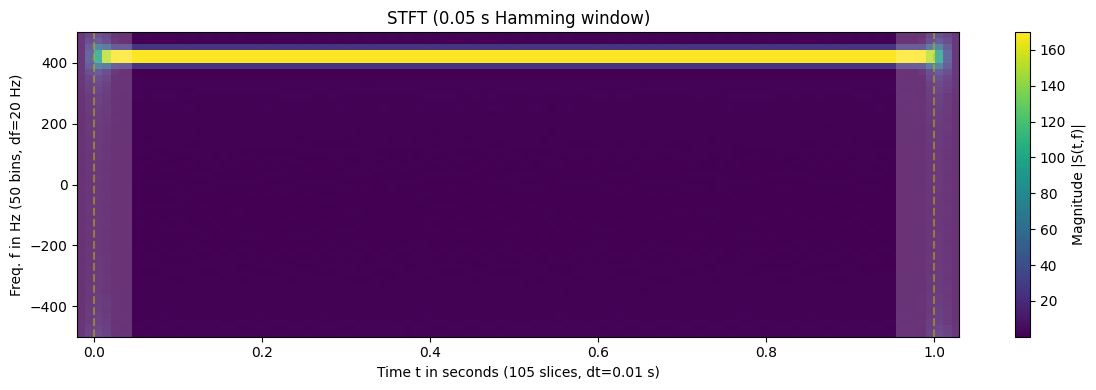

In [39]:
fig1, ax1 = plt.subplots(figsize=(12, 4))
t_lo, t_hi = SFT.extent(N)[:2]

ax1.set_title(f"STFT ({SFT.m_num * SFT.T:g} s Hamming window)")
ax1.set(
    xlabel=f"Time t in seconds ({SFT.p_num(N)} slices, dt={SFT.delta_t:g} s)",
    ylabel=f"Freq. f in Hz ({SFT.f_pts} bins, df={SFT.delta_f:g} Hz)",
    xlim=(t_lo, t_hi)
)

im1 = ax1.imshow(abs(SFy), origin='lower', aspect='auto',
                 extent=SFT.extent(N), cmap='viridis')
fig1.colorbar(im1, label="Magnitude |S(t,f)|")

for t0_, t1_ in [(t_lo, SFT.lower_border_end[0] * SFT.T),
                 (SFT.upper_border_begin(N)[0] * SFT.T, t_hi)]:
    ax1.axvspan(t0_, t1_, color='w', linewidth=0, alpha=.2)

for t_ in [0, N * SFT.T]:
    ax1.axvline(t_, color='y', linestyle='--', alpha=0.5)

fig1.tight_layout()
plt.show()

## Classes for generating datasets

In [63]:
@dataclass
class DatasetMetadata:
    file_format:    str
    filename:       str
    save_path:      Path

    @classmethod
    def create_from_save_path(cls, path: Path):
        return cls(
            file_format=path.suffix.lstrip("."),
            filename=path.stem,
            save_path=path.parent
        )

@dataclass
class DataRequest:
    request_name:   str
    drone:          Drone
    radar:          Radar
    context:        Context
    noise_model:    BaseNoiseModel
    sample_size:    int

In [64]:
class SyntheticDatasetGenerator:
    def __init__(self, dataset_metadata: DatasetMetadata):
        self.dataset_metadata = dataset_metadata
        self.data_requests = []

        self._create_dataset_file()

    def _create_dataset_file(self):
        md = self.dataset_metadata
        full_path = md.save_path / f"{md.filename}.{md.file_format}"
        full_path.parent.mkdir(parents=True, exist_ok=True)

        if full_path.exists():
            warnings.warn(f"File '{full_path}' already exists. Resolving name conflict.")
            i = 1
            while full_path.exists():
                new_filename = f"{md.filename}_({i})"
                full_path = md.save_path / f"{new_filename}.{md.file_format}"
                i += 1
            self.dataset_metadata.filename = new_filename

        if md.file_format in ("pkl",):       # For now only pkl format has the native support
            full_path.touch()
        else:
            raise ValueError(f"Unsupported file format: {md.file_format}")

    def _save_data(self, data):
        md = self.dataset_metadata
        full_path = md.save_path / f"{md.filename}.{md.file_format}"
        if md.file_format == "pkl":
            with open(full_path, "ab") as f:
                pickle.dump(data, f)
        else:
            raise ValueError(f"Unsupported file format: {md.file_format}") # The code shouldn't get here, but you never know


    def append_data_requests(self, data_requests: list[DataRequest]):
        for item in data_requests:
            if not isinstance(item, DataRequest):
                raise TypeError("Submitted data_requests contain non DataRequest items")

        self.data_requests+=data_requests

    def generate_data(self):    # This is quite inefficient implementation, so if scalling is required, this has to be improved
        for req in tqdm(self.data_requests):
            sig_gen = SyntheticSignalGenerator(req.drone, req.radar, req.noise_model)
            for i in range(req.sample_size):
                _, signal = sig_gen.generate_signal(req.context) # t_array can be reconstructed from request data
                data = {
                    "request": req,
                    "signal": signal
                }
                self._save_data(data)

        self.data_requests = []

## Actual generation of datasets

### Training dataset

In [65]:
PROJECT_ROOT = Path().resolve()
path = PROJECT_ROOT  / "datasets" / "training_dataset.pkl"
md = DatasetMetadata.create_from_save_path(path)

snr_values = np.arange(-60,40,5)

contexts_array = []
for snr in snr_values:
    contexts_array.append(Context(
        R = np.random.uniform(low=200, high=2000),
        V_rad = np.random.uniform(low=0, high=50),
        θ = np.random.uniform(low=np.pi/16, high=np.pi/2),
        Φ_p = np.random.uniform(low=0, high=np.pi/4),
        A_r = np.random.chisquare(4),
        snr = snr,
        t_start = 0,
        t_stop = 1,
        dt = 0.001
    ))


data_requests_array = []
for cont in contexts_array:
    data_req = DataRequest(
        request_name    = f"snr={cont.snr}",
        drone           = djimavicair2,
        radar           = default_radar,
        context         = cont,
        noise_model     = AdditiveWhiteGaussianNoise(),
        sample_size     = 800
    )
    data_requests_array.append(data_req)

In [66]:
dataset_gen = SyntheticDatasetGenerator(dataset_metadata=md)
dataset_gen.append_data_requests(data_requests=data_requests_array)
dataset_gen.generate_data()

100%|██████████| 20/20 [03:17<00:00,  9.86s/it]


### Validating dataset

In [67]:
PROJECT_ROOT = Path().resolve()
path = PROJECT_ROOT  / "datasets" / "validating_dataset.pkl"
md = DatasetMetadata.create_from_save_path(path)

snr_values = np.arange(-60,40,5)

contexts_array = []
for snr in snr_values:
    contexts_array.append(Context(
        R = np.random.uniform(low=200, high=2000),
        V_rad = np.random.uniform(low=0, high=50),
        θ = np.random.uniform(low=np.pi/16, high=np.pi/2),
        Φ_p = np.random.uniform(low=0, high=np.pi/4),
        A_r = np.random.chisquare(4),
        snr = snr,
        t_start = 0,
        t_stop = 1,
        dt = 0.001
    ))


data_requests_array = []
for cont in contexts_array:
    data_req = DataRequest(
        request_name    = f"snr={cont.snr}",
        drone           = djimavicair2,
        radar           = default_radar,
        context         = cont,
        noise_model     = AdditiveWhiteGaussianNoise(),
        sample_size     = 200
    )
    data_requests_array.append(data_req)

In [68]:
dataset_gen = SyntheticDatasetGenerator(dataset_metadata=md)
dataset_gen.append_data_requests(data_requests=data_requests_array)
dataset_gen.generate_data()

100%|██████████| 20/20 [00:48<00:00,  2.41s/it]


### Testing dataset

In [69]:
PROJECT_ROOT = Path().resolve()
path = PROJECT_ROOT  / "datasets" / "testing_dataset.pkl"
md = DatasetMetadata.create_from_save_path(path)

snr_values = np.arange(-60,40,5)

contexts_array = []
for snr in snr_values:
    contexts_array.append(Context(
        R = np.random.uniform(low=200, high=2000),
        V_rad = np.random.uniform(low=0, high=50),
        θ = np.random.uniform(low=np.pi/16, high=np.pi/2),
        Φ_p = np.random.uniform(low=0, high=np.pi/4),
        A_r = np.random.chisquare(4),
        snr = snr,
        t_start = 0,
        t_stop = 1,
        dt = 0.001
    ))


data_requests_array = []
for cont in contexts_array:
    data_req = DataRequest(
        request_name    = f"snr={cont.snr}",
        drone           = djimavicair2,
        radar           = default_radar,
        context         = cont,
        noise_model     = AdditiveWhiteGaussianNoise(),
        sample_size     = 100
    )
    data_requests_array.append(data_req)

In [70]:
dataset_gen = SyntheticDatasetGenerator(dataset_metadata=md)
dataset_gen.append_data_requests(data_requests=data_requests_array)
dataset_gen.generate_data()

100%|██████████| 20/20 [00:23<00:00,  1.17s/it]
